# M4-B2 — Vision PCB Defect (binôme async)

Auteurs : `<prénom1>` × `<prénom2>` — Date : `<date>`

**Conventions** :
- `random_state=42`
- Pas de `print` excessif
- `Co-authored-by:` sur les commits significatifs

In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

sys.path.append('..')  # racine du repo → permet les imports « package » src.*
from src.load_data import CLASSES, get_dataloaders

DATA_DIR = Path('../data/pcb_defect_sample')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

Device : cpu


## 1. EDA dataset PCB (~1h binôme)

- Distribution des 7 classes (déséquilibre ?)
- Visualisation 7×3 subplot (3 exemples par classe)
- Notes : qualité d'image, variabilité intra-classe, ambiguïtés

Total images : 2100
  ok            300  (14.3 %)
  open          300  (14.3 %)
  short         300  (14.3 %)
  mousebite     300  (14.3 %)
  spur          300  (14.3 %)
  copper        300  (14.3 %)
  pin_hole      300  (14.3 %)


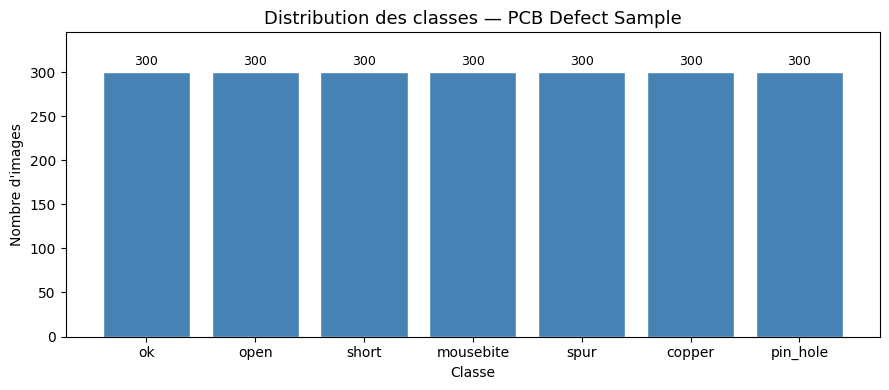

In [10]:
from collections import Counter

# --- Comptage par classe ---
counts = Counter()
for cls in CLASSES:
    cls_dir = DATA_DIR / cls
    counts[cls] = len(list(cls_dir.glob("*.png"))) if cls_dir.is_dir() else 0

total = sum(counts.values())
print(f"Total images : {total}")
for cls in CLASSES:
    n = counts[cls]
    print(f"  {cls:<12} {n:>4}  ({n/total*100:.1f} %)")

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(CLASSES, [counts[c] for c in CLASSES], color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="%d", padding=3, fontsize=9)
ax.set_title("Distribution des classes — PCB Defect Sample", fontsize=13)
ax.set_xlabel("Classe")
ax.set_ylabel("Nombre d'images")
ax.set_ylim(0, max(counts.values()) * 1.15)
plt.tight_layout()
plt.show()


Seulement 300 images par classe, donc maximum ResNet18.

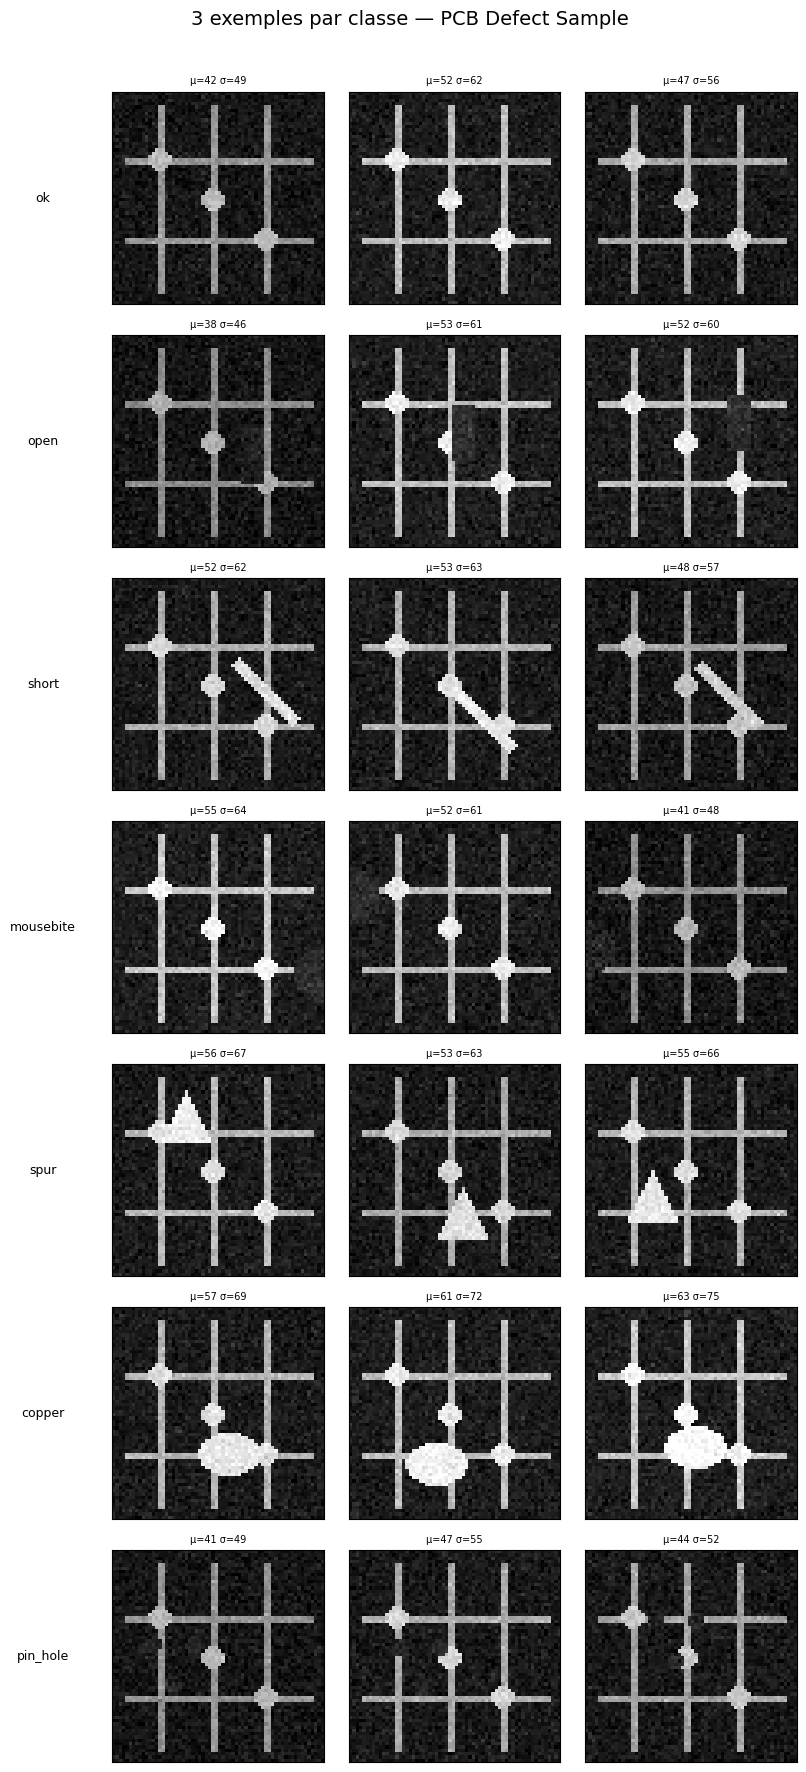

In [12]:
import random

random.seed(42)
N_EXAMPLES = 3

fig, axes = plt.subplots(len(CLASSES), N_EXAMPLES, figsize=(N_EXAMPLES * 2.8, len(CLASSES) * 2.5))
fig.suptitle("3 exemples par classe — PCB Defect Sample", fontsize=14, y=1.01)

for row, cls in enumerate(CLASSES):
    cls_dir = DATA_DIR / cls
    images = sorted(cls_dir.glob("*.png"))
    sample = random.sample(images, min(N_EXAMPLES, len(images)))

    for col in range(N_EXAMPLES):
        ax = axes[row][col]
        if col < len(sample):
            img = Image.open(sample[col]).convert("L")
            # stats rapides
            arr = np.array(img)
            ax.imshow(arr, cmap="gray", vmin=0, vmax=255)
            ax.set_title(f"μ={arr.mean():.0f} σ={arr.std():.0f}", fontsize=7)
        else:
            ax.axis("off")

        if col == 0:
            ax.set_ylabel(cls, fontsize=9, rotation=0, labelpad=50, va="center")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()


Notes EDA :
- Images 64×64 px, niveaux de gris (1 canal)
- Classe 'ok' : fond uniforme, traces nettes — référence propre
- Défauts visuels : copper/spur/open souvent subtils (faible contraste local)
- mousebite / pin_hole : petites lacunes ponctuelles → variabilité de position importante
- Les images sont normalisées en X/Y/Z (horizon à 0 systématiquement et zoom identique)

## 2. Implémentation de l'option choisie (~4h binôme)

Cf. `decisions.md` pour le choix (A / B / C).

- Option A : `src/option_a_cnn.py`
- Option B : `src/option_b_transfer.py`
- Option C : `src/option_c_clip.py`

In [13]:
# TODO — entraîner ou inférer l'option choisie
# Import : from src.option_a_cnn import SimpleCNN, train_one_epoch, evaluate  (idem b/c)
# Mesure : temps train (si options A ou B), latence inférence (toutes options), accuracy

## 3. Comparaison économique 3 approches (~1h30)

Voir `economic_comparison.md` à remplir.

## 4. Verdict + préparation restitution duo (~1h30)

- `verdict.md` : recommandation, 8 lignes max
- Préparation restitution mardi 1ᵉʳ sept (rentrée M5) : qui dit quoi ?